# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [Arya]

**Date:** [09/02]

In [ ]:
# Your Phase 1 solution to the problem goes here.

In [1]:
# Question 1.1

from google.colab import files
uploaded = files.upload()


Saving GSAF5.xls to GSAF5.xls


In [ ]:
#importing pandas and uploading csv into collab and using df.head which gives first five rows to get a sense of what the data looks like
import pandas as pd
df = pd.read_csv("airbnb_hw.csv")
df.head()

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,5162530,NaN,1 Bedroom in Prime Williamsburg,Brooklyn,Apartment,NaN,Entire home/apt,11249.0,1.0,1,0,145,NaN
1,33134899,NaN,"Sunny, Private room in Bushwick",Brooklyn,Apartment,NaN,Private room,11206.0,1.0,1,1,37,NaN
2,39608626,NaN,Sunny Room in Harlem,Manhattan,Apartment,NaN,Private room,10032.0,1.0,1,1,28,NaN
3,500,6/26/2008,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN
4,500,6/26/2008,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0


In [ ]:
#Using the describe function to understand a little more about the price column and seeing that it is the wrong data type
df["Price"].describe()

,Price
count,30478
unique,511
top,150
freq,1481


In [ ]:
#Deleting any commas in the price column by replacing the comma with nothing in order to be able to convert it to numeric
df["Price"] = df["Price"].replace(",", "", regex=True)

In [ ]:
#converting data type to integers as opposed to string/object
df["Price"] = pd.to_numeric(df["Price"])

In [ ]:
#checking that a row that I know has a comma no longer has one
#checking that the max value in the price column is correct and no longer displaying as 999
df.iloc[101]
df["Price"].max()

10000

In [ ]:
#checking that there are no errors
df["Price"].isna().sum()

np.int64(0)

In [ ]:
#Question 1.2
from google.colab import files
uploaded = files.upload()

Saving mn_police_use_of_force.csv to mn_police_use_of_force.csv


In [ ]:
df2 = pd.read_csv("mn_police_use_of_force.csv")
df2.head()

,response_datetime,problem,is_911_call,primary_offense,subject_injury,force_type,force_type_action,race,sex,age,type_resistance,precinct,neighborhood
0,2016/01/01 00:47:36,Assault in Progress,Yes,DASLT1,NaN,Bodily Force,Body Weight to Pin,Black,Male,20.0,Tensed,1,Downtown East
1,2016/01/01 02:19:34,Fight,No,DISCON,NaN,Chemical Irritant,Personal Mace,Black,Female,27.0,Verbal Non-Compliance,1,Downtown West
2,2016/01/01 02:19:34,Fight,No,DISCON,NaN,Chemical Irritant,Personal Mace,White,Female,23.0,Verbal Non-Compliance,1,Downtown West
3,2016/01/01 02:28:48,Fight,No,PRIORI,NaN,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West
4,2016/01/01 02:28:48,Fight,No,PRIORI,NaN,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West


In [ ]:
df2["subject_injury"].describe()

,subject_injury
count,3077
unique,2
top,Yes
freq,1631


In [ ]:
# Figuring out porpotion of Nans there are by dividing the sum of NaNs with the total number of rows

x = df2["subject_injury"].isna().sum()
y = len(df2)
x/y

np.float64(0.7619342359767892)

In [ ]:
#This means that 76% of the values indicating whether the subject was injured or not are missing. This is gravely concerning as that is 3/4s of the data for that column.

In [ ]:
#Replacing the NaNs with "missing" to be able to cross tabulate and checking to ensure that it worked and that nothing was dropped
df2["subject_injury"] = df2["subject_injury"].fillna("Missing")
df2["subject_injury"].unique()
df2["subject_injury"].value_counts()

,count
subject_injury,
Missing,9848
Yes,1631
No,1446


In [ ]:
#This crosstab helps us see that the missing 76% of data for subject_injury is not random and seems to be closely correlated with the type of force used. In force types where it seems pretty likely that the police would hurt a subject (aka bodily force/chemical irritant/taser/etc.), the data for whether the subject sustained injury is conspicously missing at alarming porportions.
pd.crosstab(df2["subject_injury"], df2["force_type"])

force_type,Baton,Bodily Force,Chemical Irritant,Firearm,Gun Point Display,Improvised Weapon,Less Lethal,Less Lethal Projectile,Maximal Restraint Technique,Police K9 Bite,Taser
subject_injury,,,,,,,,,,,
Missing,2,7051,1421,0,27,74,87,0,170,31,985
No,0,1093,131,2,33,34,0,1,0,2,150
Yes,2,1286,41,0,44,40,0,2,0,44,172


In [ ]:
# question 2.1
from google.colab import files
uploaded = files.upload()

Saving GSAF5.xls to GSAF5.xls


In [2]:
import pandas as pd

In [3]:
#importing/reading excel file into dataframe
df3 = pd.read_excel("GSAF5.xls")
df3.head()

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,26th August,2026.0,Unprovoked,USA,Hawaii,"Ala Moana Beach Park, Oah'u",Surfing,Unknown Female,F,?,...,Tiger Shark,Keith Cowley: KHON: KITV:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,23rd August,2026.0,Unprovoked,USA,Florida,Boca Grande (island in the keys),Wading on a sandbar,David Daniel,M,43,...,Large shark,Keith Cowley: Todd Smith: NBC 6: ABC News:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,19th August,2026.0,Provoked,Reunion Island,Saint-Gilles-les-Baines,Outer Reef Roches Noires,Spearfishiong,Male,M,?,...,Bull shark 2.5m (8.2 ft),Todd Smith: Local Report Zinfos 874:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11th August,2026.0,Provoked,Ireland,Waterford,Ardemore County,Fishing,Sebastian Achim,M,27,...,1.5m (5ft) Blue shark,Keith Cowley: David Bargh: Irish Times BBC Met...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8th August,2026.0,Unprovoked,USA,Maine,Scarborough Beach Park,Operation of Rescue Torpedo,Greg Wilfert,M,71,...,Great White Shark,WGME: CBS News: Keith Cowley,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#question 2.2

In [ ]:
#checking the columns that have only nans

df3.isna().sum()



,0
Date,0
Year,2
Type,18
Country,50
State,487
Location,567
Activity,583
Name,218
Sex,578
Age,2994


In [ ]:
#checking to make sure these don't have any data in them
df3['Unnamed: 22'].unique()
df3['Unnamed: 21'].unique()

array([nan, 'stopped here'], dtype=object)

In [4]:
#dropping columns that have more less than 3 non NAN values
df3 = df3.dropna(axis=1, thresh=3)
df3.head()

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Fatal Y/N,Time,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order
0,26th August,2026.0,Unprovoked,USA,Hawaii,"Ala Moana Beach Park, Oah'u",Surfing,Unknown Female,F,?,...,N,1330hrs,Tiger Shark,Keith Cowley: KHON: KITV:,NaN,NaN,NaN,NaN,NaN,NaN
1,23rd August,2026.0,Unprovoked,USA,Florida,Boca Grande (island in the keys),Wading on a sandbar,David Daniel,M,43,...,N,1700hrs,Large shark,Keith Cowley: Todd Smith: NBC 6: ABC News:,NaN,NaN,NaN,NaN,NaN,NaN
2,19th August,2026.0,Provoked,Reunion Island,Saint-Gilles-les-Baines,Outer Reef Roches Noires,Spearfishiong,Male,M,?,...,N,?,Bull shark 2.5m (8.2 ft),Todd Smith: Local Report Zinfos 874:,NaN,NaN,NaN,NaN,NaN,NaN
3,11th August,2026.0,Provoked,Ireland,Waterford,Ardemore County,Fishing,Sebastian Achim,M,27,...,N,1615hrs,1.5m (5ft) Blue shark,Keith Cowley: David Bargh: Irish Times BBC Met...,NaN,NaN,NaN,NaN,NaN,NaN
4,8th August,2026.0,Unprovoked,USA,Maine,Scarborough Beach Park,Operation of Rescue Torpedo,Greg Wilfert,M,71,...,N,1300hrs,Great White Shark,WGME: CBS News: Keith Cowley,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# question 2.3
#chekcing if there is any nans
df3[df3['Year'].isna()]


,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Fatal Y/N,Time,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order
970,Reported 08-Jan-2017,NaN,Invalid,AUSTRALIA,Queensland,NaN,Spearfishing,Kerry Daniel,M,35,...,NaN,NaN,Bull shark,Liquid Vision 1/8/2017,2017.01.08.R-KerryDaniel.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2017.01.08.R,2017.01.08.R,6142.0
6885,Reported 19-Aug-1836,NaN,Unprovoked,ENGLAND,Cumberland,Whitehaven,Swimming,a boy,M,NaN,...,Y,NaN,NaN,"C. Moore, GSAF",1835.08.19.R-Whitehaven.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,1836.08.19.R,1836.08.19.R,230.0


In [ ]:
#changing the data type from float to integer to get rid of decimals
df3['Year'] = df3['Year'].astype('Int64')
df3["Year"].value_counts()


,count
Year,
2015,143
2017,141
2016,133
0,129
2011,128
...,...
1738,1
1723,1
1721,1


In [ ]:
#There are rows that say before 1960 and also BCE dates. NOt sure how to deal with that. Strictly dealing with CE dates, teh lowest is 5 CE and the highest is 2026 CE
df3["Year"].describe()

,Year
count,7115.0
mean,1936.549122
std,269.943193
min,0.0
25%,1948.0
50%,1987.0
75%,2010.0
max,2026.0


<Axes: xlabel='Year'>

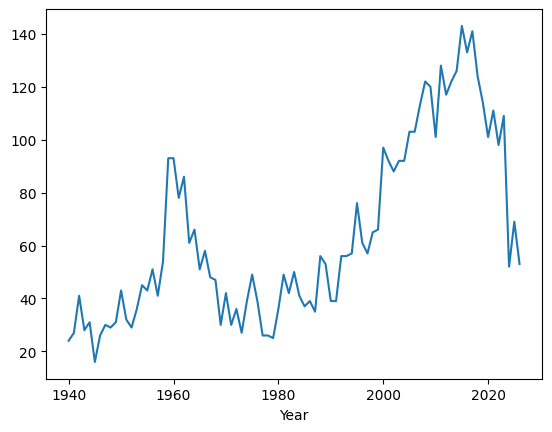

In [ ]:
#filtering dataframe to just attacks where year is greater than 1940
#and then seeing the number of rows per year to see a pattern by making a graph.
#The attacks are increasing and decreasig in various periods. It spikes in 1960 and then declines until the 80s and then climbs into the mid-2010s and then starts to drop again.
df3_1940 = df3[df3["Year"] >= 1940]

df3_1940["Year"].value_counts().sort_index().plot()

In [ ]:
#question 2.4
df3["Age"].describe()


,Age
count,4123
unique,252
top,16
freq,92


In [ ]:
# There's a bunch of weird formats that need to be all numeric
df3["Age"].apply(type).value_counts()

In [ ]:
#changes everything in a weird format into NAN
df3["Age"] = pd.to_numeric(df3["Age"], errors="coerce")

(array([ 141., 1075.,  998.,  678.,  418.,  322.,  197.,   79.,   34.,
           6.]),
 array([ 1. ,  9.6, 18.2, 26.8, 35.4, 44. , 52.6, 61.2, 69.8, 78.4, 87. ]),
 <BarContainer object of 10 artists>)

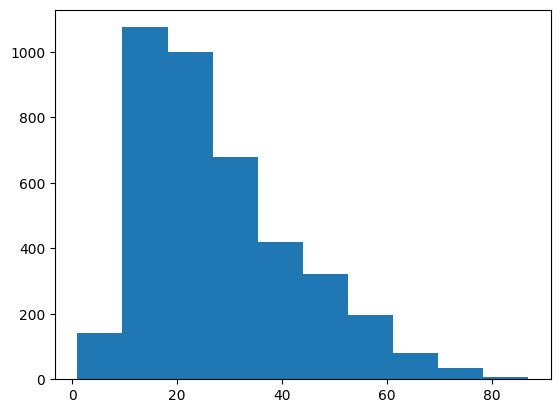

In [ ]:
import matplotlib.pyplot as plt
plt.hist(df3["Age"])

In [ ]:
#question 2.5

#There are two Ms and two Fs and other formats. Going to take away any spaces for the extra F and M, so that they can combine
df3["Sex"] = df3["Sex"].str.strip()

#there is one lowercase m, so changing it to uppercase

df3["Sex"] = df3["Sex"].replace("m", "M")

#N is probably a mistype of M

df3["Sex"] = df3["Sex"].replace("N", "M")

#everything else replaced with Nan

df3.loc[~df3["Sex"].isin(["M", "F"]), "Sex"] = float("NaN")

df3["Sex"].value_counts()

,count
Sex,
M,5715
F,818


In [ ]:
# find porpotion of men = 87.5%
x = 5715
y = 5715 + 818
x/y

0.8747895300780653

In [ ]:
#Quetsion 2.6
#There are other formats. Going to take away any spaces, so that they can combine

df3["Type"] = df3["Type"].str.strip()

#fix mispellings
df3["Type"] = df3["Type"].replace("unprovoked", "Unprovoked")
df3["Type"] = df3["Type"].replace("UNprovoked", "Unprovoked")

#combine the questionables
df3["Type"] = df3["Type"].replace("Questionable", "Unknown")
df3["Type"] = df3["Type"].replace("Unconfirmed", "Unknown")
df3["Type"] = df3["Type"].replace("Unverified", "Unknown")
df3["Type"] = df3["Type"].replace("Under investigation", "Unknown")
df3["Type"] = df3["Type"].replace("?", "Unknown")

#everything else into nan

df3.loc[~df3["Type"].isin(["Provoked", "Unprovoked", "Unknown"]), "Type"] = float("NaN")

df3["Type"].value_counts()

,count
Type,
Unprovoked,5263
Provoked,649
Unknown,31


In [ ]:
#porpotion of unprovoked is 88.6%
x = 5263
y = 5263 + 649 + 31
x/y

0.8855796735655392

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [77b75c8]
- **AI tool and model used:** [chatgpt 5.6]

### *Prompts used

1. [Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?

this is what I have and I don't know how to deal with the missing values that have corresponding dates in year with 5 ad and BCE

#changing the data type from float to integer to get rid of decimals
df3['Year'] = df3['Year'].astype('Int64')

df3["Year"].value_counts()

#There are rows that say before 1960 and also BCE dates. NOt sure how to deal with that. Strictly dealing with CE dates, teh lowest is 5 CE and the highest is 2026 CE

df3["Year"].describe()

#filtering dataframe to just attacks where year is greater than 1940

#and then seeing the number of rows per year to see a pattern by making a graph.

#The attacks are increasing and decreasig in various periods. It spikes in 1960 and then declines until the 80s and then climbs into the mid-2010s and then starts to drop again.

df3_1940 = df3[df3["Year"] >= 1940]

df3_1940["Year"].value_counts().sort_index().plot()
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. I'd clean it first and convert to Int64 afterward.

For example, if there are weird/non-numeric values in Year, start with: df3["Year"] = pd.to_numeric(df3["Year"], errors="coerce")
2. df3.loc[df3["Year"].isna(), ["Date", "Year"]]

3. Once you've dealt with any obvious missing years that can be recovered from Date, this is perfectly good: df3["Year"] = df3["Year"].astype("Int64")

df3["Year"].describe()

4. df3_1940 = df3[df3["Year"] >= 1940]

df3_1940["Year"].value_counts().sort_index().plot()

5. df3_1940["Year"].value_counts().sort_index().plot(
    xlabel="Year",
    ylabel="Number of attacks",
    title="Shark Attacks per Year Since 1940"
)

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject I accept the suggestions to inspect the date column to help with year column. I also accept suggestion to inspect and clean and then switch to integer and coerce errors as it suggested it makes it harder to clean after changing type is already done.
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

<Axes: title={'center': 'Shark Attacks per Year Since 1940'}, xlabel='Year', ylabel='Number of attacks'>

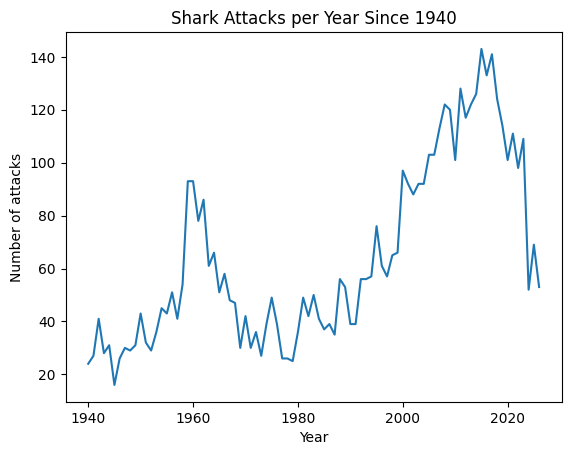

In [5]:
# Your Phase 2 solution to the problem goes here.
# Clean the Year variable:
# Convert anything that cannot be interpreted as a number to NaN.
# Do this before converting Year to an integer.
df3["Year"] = pd.to_numeric(df3["Year"], errors="coerce")


# Check rows where Year is missing.
# Some of these may have a usable year in the Date column.
df3.loc[df3["Year"].isna(), ["Date", "Year"]]


# The dataset contains very old observations, including BCE dates and early CE dates.
# These are not necessarily errors. BCE dates cannot be represented properly as
# ordinary positive years, so I am not forcing them into the Year variable.
# If a missing Year has a clearly identifiable year in Date, that year could be
# recovered from Date. Otherwise, the Year remains missing.


# Convert Year to nullable integer type to remove the .0 decimals
# while still allowing missing values.
df3["Year"] = df3["Year"].astype("Int64")


# Examine the range of Year values.
df3["Year"].describe()

# The dataset contains BCE dates as well as CE dates.
# Among the CE dates, the years range from very early historical observations
# (including 5 CE) through 2026.


# Filter the dataframe to attacks since 1940.
# Missing years are automatically excluded because NaN >= 1940 is not True.
df3_1940 = df3[df3["Year"] >= 1940]


# Count the number of recorded attacks in each year and graph the results.
df3_1940["Year"].value_counts().sort_index().plot(
    xlabel="Year",
    ylabel="Number of attacks",
    title="Shark Attacks per Year Since 1940"
)

# Overall, recorded shark attacks have increased since 1940, although the trend
# is not consistent. There is a spike around 1960, followed by a decline, and
# then a substantial increase beginning around the 1980s and continuing into
# the mid-2010s. Recorded attacks decline again in the most recent years.
#
# However, 2026 is an incomplete year, so its lower number of attacks should
# not be interpreted as evidence of a decline by itself.

### *Reflection on AI assistance
In your own words without generative AI.

AI helped me improve the cleaning of the Year variable. Initially, I only converted Year to an integer, which changed its format but did not address potentially invalid values. AI suggested using pd.to_numeric(..., errors="coerce"), which converted values that cannot be interpreted as numerical years to missing values.